# From Signals to Returns: The Reality Check

**Docker image**: `ml4t`

**Purpose**: pedagogical end-to-end backtest comparing ML-generated signals
against momentum and equal-weight baselines on the ETF panel. Shows what
happens to a ranking signal once turnover and transaction costs are charged
against it.

**Learning objectives**

- Train Ridge and Logistic models on the canonical 8-fold walk-forward CV
- Convert signals to long-only top-10 portfolios with equal weights
- Compute gross / net Sharpe, annualized return, volatility, drawdown, and
  turnover
- Quantify how transaction-cost drag, charged at `COST_BPS` per side, separates
  high-turnover ML strategies from low-turnover baselines

**Book reference**: Section 11.6 - Linear Models Across Nine Case Studies
(the chapter synthesis paragraph on IC vs net Sharpe).

**Prerequisites**

- Ch7 21-day forward return labels at `case_studies/etfs/labels/fwd_ret_21d.parquet`
- Ch8 ETF features at `case_studies/etfs/features/financial.parquet`
- ETF prices via `data.load_etfs()`
- `setup.yaml` evaluation section for canonical walk-forward splits

**Caveat**: this is a deliberately simplified backtest for pedagogy.
Production backtesting with proper execution modeling, slippage, and risk
management is covered in *Chapter 16*. Portfolio construction with turnover
constraints is *Chapter 17*; transaction-cost modeling is *Chapter 18*.

In [1]:
"""From Signals to Returns: The Reality Check - a pedagogical backtest of ranking signals net of cost."""

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import Markdown, display
from ml4t.diagnostic.metrics import cross_sectional_ic_series
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler

from data import load_etfs
from utils.cv_splits import generate_cv_splits
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, show_with_alt

In [2]:
SEED = 42
TOP_N = 10
COST_BPS = 10
MAX_SYMBOLS = 0
MAX_FOLDS = 0

In [3]:
set_global_seeds(SEED)

In [4]:
CASE_DIR = get_case_study_dir("etfs")

TRADING_DAYS_PER_YEAR = 252

## Load Data

Features from Ch8, labels from Ch7, ETF prices from the canonical loader, and the canonical
walk-forward CV splits from the `setup.yaml` evaluation section.

In [5]:
features = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
labels = pl.read_parquet(CASE_DIR / "labels" / "fwd_ret_21d.parquet")

prices = (
    load_etfs()
    .sort("symbol", "timestamp")
    .with_columns(daily_ret=pl.col("close").pct_change().over("symbol"))
)

print(f"Features: {features.shape[0]:,} rows, {features['symbol'].n_unique()} assets")
print(f"Labels:   {labels.shape[0]:,} rows")

Features: 404,500 rows, 99 assets
Labels:   468,562 rows


In [6]:
# Join features + labels
data = features.join(labels, on=["timestamp", "symbol"], how="inner").drop_nulls(
    subset=["fwd_ret_21d"]
)

if MAX_SYMBOLS > 0:
    keep_assets = data["symbol"].unique().sort().head(MAX_SYMBOLS).to_list()
    data = data.filter(pl.col("symbol").is_in(keep_assets))
    prices = prices.filter(pl.col("symbol").is_in(keep_assets))

EXCLUDE = {"timestamp", "symbol", "regime", "fwd_ret_21d"}
feature_cols = [c for c in data.columns if c not in EXCLUDE and data[c].dtype.is_numeric()]
print(f"Combined: {data.shape[0]:,} rows, {len(feature_cols)} features")

Combined: 402,526 rows, 56 features


In [7]:
# Generate walk-forward CV splits from setup.yaml evaluation section
splits = generate_cv_splits(data, case_study_id="etfs", label_buffer="21D")
if MAX_FOLDS > 0:
    splits = splits[:MAX_FOLDS]
print(f"CV folds: {len(splits)}")

CV folds: 8


## Walk-Forward Prediction

The splits come from the `evaluation` section of the case study's `setup.yaml`, which
declares eight folds of ten years' training and one year's validation, stepping
forward annually. `label_buffer="21D"` purges the 21 sessions a 21-day forward label
needs, so no training row's label resolves inside its own validation window. The cell
above prints how many folds this run actually used.

For each fold we train Ridge and Logistic once, then predict across the entire validation window.
Momentum ranks on `ret_126d` directly, with no training step.

In [8]:
def rank_top_n(assets, scores, top_n):
    """Select top-N symbols by score, return equal-weight dict."""
    valid = ~np.isnan(scores)
    effective_n = min(top_n, int(valid.sum()))
    if effective_n == 0:
        return {}
    order = np.argsort(-np.where(valid, scores, -np.inf))
    selected = [assets[i] for i in order[:effective_n]]
    w = 1.0 / effective_n
    return {s: w for s in selected}

Ridge and Logistic are fitted once per fold on that fold's training window, at the
library's default regularization strengths. Choosing those strengths honestly is
`04_nested_cv_hpo`; what this notebook varies is what happens to a signal once it is
traded.

In [9]:
fold_models = []

for fold in splits:
    fold_num = fold["fold"]
    train_start = date.fromisoformat(str(fold["train_start"])[:10])
    train_end = date.fromisoformat(str(fold["train_end"])[:10])
    val_start = date.fromisoformat(str(fold["val_start"])[:10])
    val_end = date.fromisoformat(str(fold["val_end"])[:10])

    train = data.filter((pl.col("timestamp") >= train_start) & (pl.col("timestamp") <= train_end))
    val = data.filter((pl.col("timestamp") >= val_start) & (pl.col("timestamp") <= val_end))

    if len(train) == 0 or len(val) == 0:
        print(f"  Fold {fold_num}: skipped (no data)")
        continue

    X_train = np.nan_to_num(train.select(feature_cols).to_numpy(), nan=0.0)
    y_train = train["fwd_ret_21d"].to_numpy()

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)

    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_s, y_train)

    y_dir = (y_train > 0).astype(int)
    logit = LogisticRegression(C=1.0, max_iter=200, solver="lbfgs")
    logit.fit(X_train_s, y_dir)

    fold_models.append((fold_num, scaler, ridge, logit, val, len(train)))

train_summary = pl.DataFrame(
    {"Fold": [fm[0] for fm in fold_models], "Train rows": [fm[5] for fm in fold_models]}
)
train_summary

Fold,Train rows
i64,i64
0,165185
1,187411
2,199520
3,208607
4,214455
5,220518
6,224830
7,228866


### Signal-to-Portfolio Conversion

For each month-end rebalance date within the validation window, we rank
symbols by each signal and select the top-N for equal-weight long portfolios.
Momentum ranks on `ret_126d` directly, with no model.

In [10]:
all_predictions = []
all_weights = []

for fold_num, scaler, ridge, logit, val, _ in fold_models:
    val_dates = val.select("timestamp").unique().sort("timestamp")["timestamp"].to_list()
    reb_dates = []
    for i, d in enumerate(val_dates):
        if i + 1 < len(val_dates):
            if val_dates[i + 1].month != d.month:
                reb_dates.append(d)
    if val_dates:
        reb_dates.append(val_dates[-1])

    for reb_date in reb_dates:
        cs = val.filter(pl.col("timestamp") == reb_date)
        if len(cs) < TOP_N:
            continue

        assets = cs["symbol"].to_list()
        n_assets = len(assets)
        y_actual = cs["fwd_ret_21d"].to_numpy()
        mom_scores = cs["ret_126d"].to_numpy()

        X_val = np.nan_to_num(cs.select(feature_cols).to_numpy(), nan=0.0)
        X_val_s = scaler.transform(X_val)
        ridge_preds = ridge.predict(X_val_s)
        logit_probs = logit.predict_proba(X_val_s)[:, 1]

        all_weights.append((reb_date, "equal", {a: 1.0 / n_assets for a in assets}))
        all_weights.append((reb_date, "momentum", rank_top_n(assets, mom_scores, TOP_N)))
        all_weights.append((reb_date, "ridge", rank_top_n(assets, ridge_preds, TOP_N)))
        all_weights.append((reb_date, "logistic", rank_top_n(assets, logit_probs, TOP_N)))
        all_predictions.append((reb_date, assets, y_actual, mom_scores, ridge_preds, logit_probs))

print(f"Total: {len(all_weights)} weight snapshots across {len(fold_models)} folds")

Total: 412 weight snapshots across 8 folds


## Compute Portfolio Returns

Forward-fill weights to daily frequency and compute daily portfolio returns as
$r_{p,t} = \sum_i w_{i,t} \cdot r_{i,t}$. Turnover is measured at each rebalance date.

In [11]:
strategies = ["equal", "momentum", "ridge", "logistic"]

# Daily return matrix (date x asset)
daily_rets = (
    prices.select(["timestamp", "symbol", "daily_ret"])
    .pivot(on="symbol", index="timestamp", values="daily_ret")
    .sort("timestamp")
)

all_assets = [c for c in daily_rets.columns if c != "timestamp"]
dates_array = daily_rets["timestamp"].to_list()
ret_matrix = daily_rets.select(all_assets).to_numpy()
sym_to_idx = {s: i for i, s in enumerate(all_assets)}

In [12]:
# Get validation period boundaries
first_val = min(date.fromisoformat(str(s["val_start"])[:10]) for s in splits)
last_val = max(date.fromisoformat(str(s["val_end"])[:10]) for s in splits)

results = {}

for strat in strategies:
    strat_weights = [(d, w) for d, s, w in all_weights if s == strat]
    if not strat_weights:
        continue
    # CV splits arrive newest-first and the simulation walks dates forward, so the
    # snapshots are sorted chronologically here; left as they came, only the most recent
    # fold's weights would ever fire.
    strat_weights.sort(key=lambda dw: dw[0])

    T = len(dates_array)
    N = len(all_assets)
    port_ret = np.full(T, np.nan)
    turnover_series = np.zeros(T)

    weight_snapshots = []
    for d, w_dict in strat_weights:
        w_arr = np.zeros(N)
        for sym, wt in w_dict.items():
            if sym in sym_to_idx:
                w_arr[sym_to_idx[sym]] = wt
        weight_snapshots.append((d, w_arr))

    current_w = np.zeros(N)
    snap_idx = 0

    for t, d in enumerate(dates_array):
        # Return first on the weights held into the close, then rebalance: the signal is
        # known at that close, so the positions it implies start earning from the next bar.
        day_rets_row = ret_matrix[t]
        valid = ~np.isnan(day_rets_row)
        if current_w.sum() > 0 and valid.any():
            safe_rets = np.where(valid, day_rets_row, 0.0)
            port_ret[t] = np.dot(current_w, safe_rets)

        if snap_idx < len(weight_snapshots) and d >= weight_snapshots[snap_idx][0]:
            new_w = weight_snapshots[snap_idx][1]
            turnover_series[t] = np.sum(np.abs(new_w - current_w)) / 2.0
            current_w = new_w.copy()
            snap_idx += 1

    results[strat] = {"daily_ret": port_ret, "turnover": turnover_series}

## Performance Summary

Annualized Sharpe (gross and net of costs), return, volatility, max drawdown and
average annual turnover, over the validation window the folds span.

In [13]:
def max_drawdown(cum_returns):
    """Maximum drawdown from cumulative return series."""
    peak = np.maximum.accumulate(cum_returns)
    dd = (cum_returns - peak) / peak
    return float(np.nanmin(dd))

In [14]:
# Compute annualized metrics for each strategy over the test period
mask = np.array([first_val <= d <= last_val for d in dates_array])
dates_bt = [d for d, m in zip(dates_array, mask, strict=False) if m]

summary_rows = []
for strat in strategies:
    r = results[strat]["daily_ret"]
    to = results[strat]["turnover"]

    r_bt = r[mask]
    to_bt = to[mask]
    valid = ~np.isnan(r_bt)
    r_clean = r_bt[valid]

    if len(r_clean) == 0:
        continue

    ann_ret = float(np.mean(r_clean) * TRADING_DAYS_PER_YEAR)
    ann_vol = float(np.std(r_clean, ddof=1) * np.sqrt(TRADING_DAYS_PER_YEAR))
    sharpe_gross = ann_ret / ann_vol if ann_vol > 0 else 0.0

    # Turnover is one-sided; multiply by 2 so COST_BPS is charged on each leg
    # (buy + sell), i.e. COST_BPS bps per side.
    cost_per_day = to_bt * 2 * COST_BPS / 10_000
    r_net = r_bt - cost_per_day
    r_net_clean = r_net[valid]
    ann_ret_net = float(np.mean(r_net_clean) * TRADING_DAYS_PER_YEAR)
    sharpe_net = ann_ret_net / ann_vol if ann_vol > 0 else 0.0

    cum = np.cumprod(1 + r_clean)
    mdd = max_drawdown(cum)

    n_years = len(r_clean) / TRADING_DAYS_PER_YEAR
    ann_turnover = float(to_bt.sum() / n_years) if n_years > 0 else 0.0

    summary_rows.append(
        {
            "strategy": strat,
            "sharpe_gross": round(sharpe_gross, 2),
            "sharpe_net": round(sharpe_net, 2),
            "ann_return_pct": round(ann_ret * 100, 1),
            "ann_vol_pct": round(ann_vol * 100, 1),
            "max_dd_pct": round(mdd * 100, 1),
            "ann_turnover_pct": round(ann_turnover * 100, 0),
        }
    )

summary = pl.DataFrame(summary_rows)
summary

strategy,sharpe_gross,sharpe_net,ann_return_pct,ann_vol_pct,max_dd_pct,ann_turnover_pct
str,f64,f64,f64,f64,f64,f64
"""equal""",0.6,0.6,8.7,14.6,-30.5,9.0
"""momentum""",0.45,0.39,8.5,19.0,-38.5,491.0
"""ridge""",0.46,0.39,9.6,21.0,-45.5,708.0
"""logistic""",0.63,0.53,9.0,14.4,-16.9,705.0


## Equity Curves and Turnover

Two panels over the validation window: growth of \$1 on top, where a solid line is
gross and the dashed line of the same colour is that strategy net of cost, and
one-sided turnover at each monthly rebalance below.

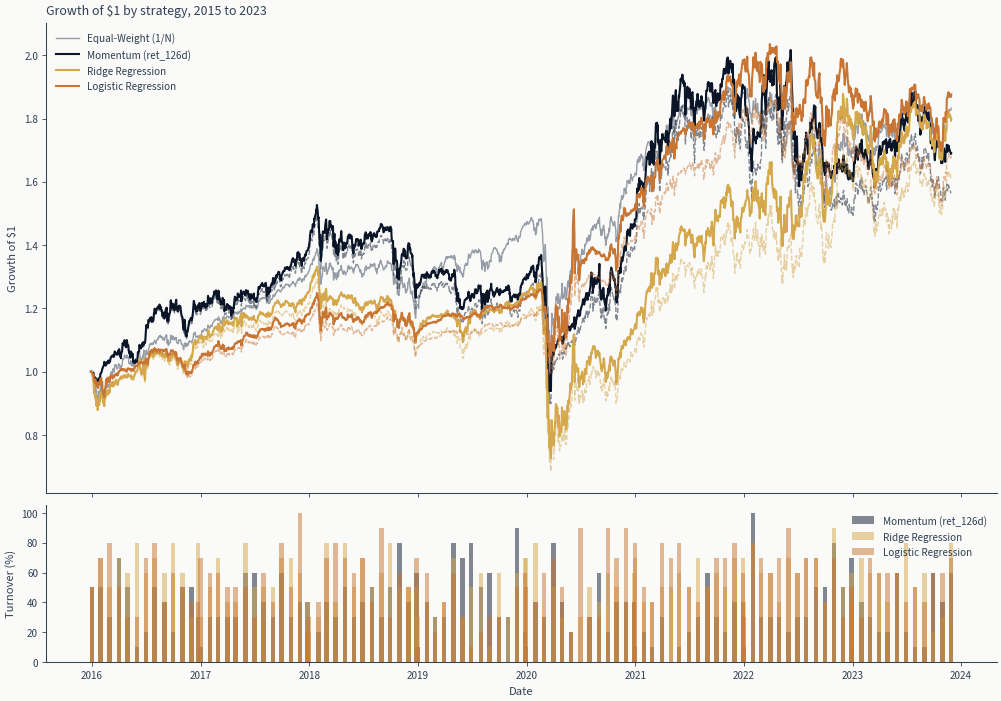

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), height_ratios=[3, 1], sharex=True)

colors = {
    "equal": COLORS["neutral"],
    "momentum": COLORS["blue"],
    "ridge": COLORS["amber"],
    "logistic": COLORS["copper"],
}
labels_map = {
    "equal": "Equal-Weight (1/N)",
    "momentum": "Momentum (ret_126d)",
    "ridge": "Ridge Regression",
    "logistic": "Logistic Regression",
}

for strat in strategies:
    r = results[strat]["daily_ret"][mask]
    to = results[strat]["turnover"][mask]
    valid = ~np.isnan(r)
    # Gross returns (solid lines)
    cum = np.cumprod(1 + np.where(valid, r, 0.0))
    lw = 1.0 if strat == "equal" else 1.5
    alpha = 0.5 if strat == "equal" else 1.0
    ax1.plot(dates_bt, cum, label=labels_map[strat], color=colors[strat], linewidth=lw, alpha=alpha)
    # Net-of-cost returns (dashed lines, skip equal-weight)
    if strat != "equal":
        cost_daily = to * 2 * COST_BPS / 10_000
        r_net = np.where(valid, r - cost_daily, 0.0)
        cum_net = np.cumprod(1 + r_net)
        ax1.plot(dates_bt, cum_net, color=colors[strat], linewidth=1.0, alpha=0.5, linestyle="--")

ax1.set_ylabel(r"Growth of \$1")
ax1.legend(loc="upper left", frameon=False, fontsize=8)
ax1.set_title(rf"Growth of \$1 by strategy, {first_val:%Y} to {last_val:%Y}")

# Monthly turnover bars
for strat in ["momentum", "ridge", "logistic"]:
    to = results[strat]["turnover"][mask]
    reb_mask = to > 0
    reb_dates_plot = [d for d, m in zip(dates_bt, reb_mask, strict=False) if m]
    reb_to_plot = to[reb_mask] * 100
    ax2.bar(
        reb_dates_plot,
        reb_to_plot,
        width=15,
        alpha=0.5,
        label=labels_map[strat],
        color=colors[strat],
    )

ax2.set_ylabel("Turnover (%)")
ax2.set_xlabel("Date")
ax2.legend(loc="upper right", frameon=False, fontsize=8)

show_with_alt(
    fig,
    "Two panels on a shared date axis. Top: cumulative growth of one dollar, one solid line "
    "per strategy for gross returns, and for the three active strategies a dashed line of "
    "the same colour for that strategy net of cost. Equal weight is drawn gross only. "
    "Bottom: one-sided turnover as bars at each monthly rebalance, for those three.",
)

## IC Comparison

Cross-sectional IC per rebalance date, smoothed over a rolling twelve rebalances. IC
scores the ranking; the equity curves above score what holding that ranking cost.

In [16]:
# One row per rebalance date and asset, one prediction column per signal.
panel_rows = []
for reb_date, assets, y_actual, mom_scores, ridge_preds, logit_probs in all_predictions:
    for j, sym in enumerate(assets):
        panel_rows.append(
            {
                "timestamp": reb_date,
                "symbol": sym,
                "fwd_ret": float(y_actual[j]),
                "momentum": float(mom_scores[j]),
                "ridge": float(ridge_preds[j]),
                "logistic": float(logit_probs[j]),
            }
        )

panel_df = pl.DataFrame(panel_rows)
ret_df = panel_df.select(["timestamp", "symbol", "fwd_ret"]).rename({"fwd_ret": "forward_return"})


def _ic_series(signal_col: str) -> pl.DataFrame:
    pred_df = panel_df.select(["timestamp", "symbol", signal_col]).rename(
        {signal_col: "prediction"}
    )
    return cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    ).select(["timestamp", pl.col("ic").alias(signal_col)])


ic_df = (
    _ic_series("momentum")
    .join(_ic_series("ridge"), on="timestamp", how="full", coalesce=True)
    .join(_ic_series("logistic"), on="timestamp", how="full", coalesce=True)
    .sort("timestamp")
)

for col in ["momentum", "ridge", "logistic"]:
    ic_df = ic_df.with_columns(pl.col(col).rolling_mean(12).alias(f"{col}_12m"))

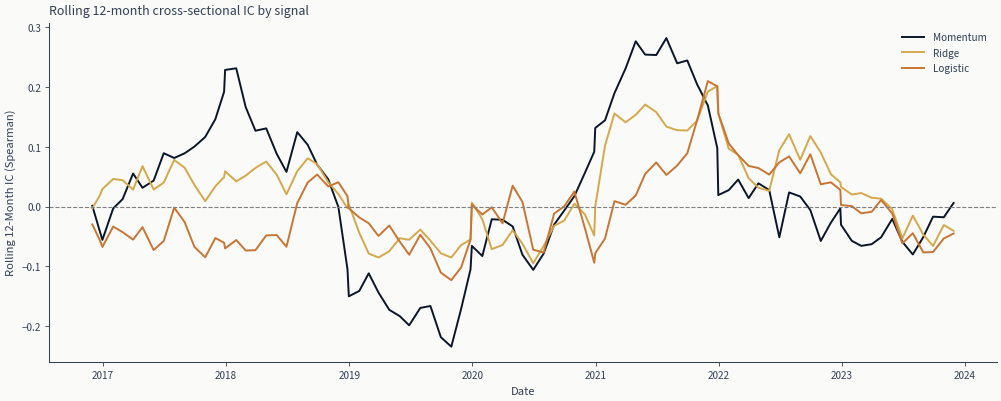

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))

for col, color, label in [
    ("momentum_12m", COLORS["blue"], "Momentum"),
    ("ridge_12m", COLORS["amber"], "Ridge"),
    ("logistic_12m", COLORS["copper"], "Logistic"),
]:
    vals = ic_df[col].to_numpy()
    dates_ic = ic_df["timestamp"].to_list()
    ax.plot(dates_ic, vals, label=label, color=color)

ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_ylabel("Rolling 12-Month IC (Spearman)")
ax.set_xlabel("Date")
ax.set_title("Rolling 12-month cross-sectional IC by signal")
ax.legend(frameon=False)
show_with_alt(
    fig,
    "Rolling 12-month cross-sectional Spearman IC for momentum, Ridge and Logistic against "
    "the rebalance date, against a dashed line at zero.",
)

# A signal scores only on dates priced by enough symbols for a rank correlation, so a
# reduced run can leave one with no defined IC at all. Report that rather than a number.
_mean_ic = {col: ic_df[col].drop_nulls().mean() for col in ["momentum", "ridge", "logistic"]}
_scored = {name: float(value) for name, value in _mean_ic.items() if value is not None}
_unscored = [name for name, value in _mean_ic.items() if value is None]

In [18]:
_metrics = {row["strategy"]: row for row in summary.iter_rows(named=True)}
_best_net = max(_metrics, key=lambda name: _metrics[name]["sharpe_net"])
_by_turnover = sorted(_metrics, key=lambda name: _metrics[name]["ann_turnover_pct"])
_drag = {name: _metrics[name]["sharpe_gross"] - _metrics[name]["sharpe_net"] for name in _metrics}
_lines = [
    (
        "- Mean cross-sectional IC: "
        + ", ".join(f"{name} {value:+.3f}" for name, value in _scored.items())
        + (f" (undefined for {', '.join(_unscored)})" if _unscored else "")
        if _scored
        else "- No signal has a defined cross-sectional IC in this run: no rebalance date "
        "carried enough symbols to rank."
    ),
    f"- Highest net Sharpe: **{_best_net}** at {_metrics[_best_net]['sharpe_net']:.2f}, "
    f"turning over {_metrics[_best_net]['ann_turnover_pct']:.0f}% a year.",
    "- Annual turnover, ascending: "
    + ", ".join(f"{name} {_metrics[name]['ann_turnover_pct']:.0f}%" for name in _by_turnover),
    f"- Sharpe given up to cost at {COST_BPS} bps per side, in the same order: "
    + ", ".join(f"{name} {_drag[name]:.2f}" for name in _by_turnover),
]
if _scored:
    _lines.insert(
        1,
        f"- Highest mean cross-sectional IC: **{max(_scored, key=lambda n: _scored[n])}**.",
    )
display(Markdown("\n".join(_lines)))

- Mean cross-sectional IC: momentum +0.020, ridge +0.021, logistic -0.009
- Highest mean cross-sectional IC: **ridge**.
- Highest net Sharpe: **equal** at 0.60, turning over 9% a year.
- Annual turnover, ascending: equal 9%, momentum 491%, logistic 705%, ridge 708%
- Sharpe given up to cost at 10 bps per side, in the same order: equal 0.00, momentum 0.06, logistic 0.10, ridge 0.07

**Interpretation.** The two rankings above are built from different things and do not
have to agree. Mean IC scores how well a signal orders next month's returns. Net
Sharpe scores what was left after holding the portfolio that ordering implies and
paying to change it. A signal can rank well and still finish behind a rule with no
signal at all, because the cost of acting on a ranking is charged against every
rebalance while the ranking itself is free.

Equal weight is the useful contrast: it holds every asset and trades only the drift
back to $1/N$ each month, so its gross and net Sharpe are nearly the same number. The
active strategies re-pick a top-N list each month and pay for the whole difference
between consecutive lists. What that takes from the annualized return is the cost rate
times the fraction traded, so return drag is proportional to turnover. The Sharpe drag
is that return drag divided by the strategy's own volatility, which is a different
ordering: of two strategies that trade the same amount, the steadier one gives up the
larger ratio.

A signal whose IC is near zero or negative can still post a respectable net Sharpe,
and the ranking is not the only thing that could produce it. A long-only top-N
portfolio drawn from a shared universe inherits most of that universe's return
whatever the ranking says, and a lower realized volatility raises the ratio without
raising the return at all. Read the IC column and the Sharpe column as answers to two
questions, not as one score twice.
Turnover-penalized objectives and trading constraints are the response, and Chapters
17 and 18 develop them.

## Key Takeaways

1. **A ranking score and a portfolio result are different measurements.** Mean IC
   says how well a signal orders the cross-section; net Sharpe says what holding the
   implied portfolio returned after costs. The table above shows how far apart the
   two orderings can be on the same eight folds.
2. **Trading is what separates them.** Cost is charged on the difference between
   consecutive weight vectors, so at a fixed cost per side the *return* a strategy
   gives up is proportional to how much it trades. The *Sharpe* it gives up is that
   return divided by its own volatility, so the steadier of two strategies that trade
   equally loses the larger ratio. Equal weight trades only its monthly drift back to
   $1/N$; a monthly top-N re-pick trades most of the book.
3. **Put transaction costs in the objective.** Regularization controls coefficient
   magnitude, not position change, so a penalized fit is not a low-turnover fit.
   Turnover-penalized objectives and trading constraints (*Chapters 17 and 18*) are
   what make a ranking signal worth acting on at this cost level.

**Next**: *Chapter 16* develops production backtesting with proper execution
modeling. *Chapter 17* adds portfolio construction with turnover constraints,
and *Chapter 18* layers in transaction-cost modeling.